# ML-02 — Research Question and Provisional Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

In [1]:
"""
Question 1: My lane and why

I chose Lane 2, after reading the lane details and the predicted capstone output.

I chose this lane for a few reasons. First, I find it a genuinely interesting
problem: how do we figure out which signals actually matter versus which are
just noise, and then turn that into an engine that ranks every page with a
reason and a recommended action. Second, I like that the outcome is a usable
product, not just a dashboard with some insights — something a reviewer could
actually act on.
"""

'\nQuestion 1: My lane and why\n\nI chose Lane 2, after reading the lane details and the predicted capstone output.\n\nI chose this lane for a few reasons. First, I find it a genuinely interesting\nproblem: how do we figure out which signals actually matter versus which are\njust noise, and then turn that into an engine that ranks every page with a\nreason and a recommended action. Second, I like that the outcome is a usable\nproduct, not just a dashboard with some insights — something a reviewer could\nactually act on.\n'

## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

In [2]:
"""
The decision this work improves is: out of all the content pages, which ones
should a reviewer look at first - and roughly why (declining, stale, thin,
low-CTR for its position, etc.). The ranked list is meant to replace guessing
based on gut feeling with an ordered queue backed by real data and a reason
attached to each page.

Who acts on it depends on the reason code attached to each page. Since the
data available here is mostly content and search performance signals
(impressions, clicks, position, freshness, word count), most flagged pages
will route to a content writer or strategist, who reviews the reason and
decides on an action - refresh, expand, protect, prune, or monitor. In
principle, a different reason code (like a user-experience issue) could
route to a different team, but this dataset doesn't include the kind of
signals (page speed, UI/UX data) needed to reliably flag that, so in
practice the reviewer here is the content team.

A wrong call has a real cost either way. If a page is flagged but is
actually fine, the reviewer wastes time and effort on it - and if they act
on it anyway, the edit could even hurt a page that didn't need touching. If
a page that genuinely needed attention gets missed or ranked too low, that's
a real, ongoing loss - traffic or income that could have been protected or
grown goes unnoticed. Since review capacity is limited, both kinds of
mistakes matter, not just one.
"""

"\nThe decision this work improves is: out of all the content pages, which ones\nshould a reviewer look at first - and roughly why (declining, stale, thin,\nlow-CTR for its position, etc.). The ranked list is meant to replace guessing\nbased on gut feeling with an ordered queue backed by real data and a reason\nattached to each page.\n\nWho acts on it depends on the reason code attached to each page. Since the\ndata available here is mostly content and search performance signals\n(impressions, clicks, position, freshness, word count), most flagged pages\nwill route to a content writer or strategist, who reviews the reason and\ndecides on an action - refresh, expand, protect, prune, or monitor. In\nprinciple, a different reason code (like a user-experience issue) could\nroute to a different team, but this dataset doesn't include the kind of\nsignals (page speed, UI/UX data) needed to reliably flag that, so in\npractice the reviewer here is the content team.\n\nA wrong call has a real co

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [3]:
from IPython.display import display
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

df=pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
display(df.info(), df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  str    
 1   client_id               30000 non-null  str    
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  str    
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  str    
 7   main_intent             27626 non-null  str    
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   str    
 11  model_used              24267 non-null  str    
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null  int64  
 

None

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [4]:
visible = df[df['impressions_90d'] > 0]
display(f"Pages with impressions > 0: {len(visible)} out of {len(df)} ({len(visible)/len(df)*100:.1f}%)")

'Pages with impressions > 0: 30000 out of 30000 (100.0%)'

count     30000.000000
mean       5200.366300
std       16838.019547
min           1.000000
25%          81.000000
50%         731.000000
75%        3615.250000
max      517715.000000
Name: impressions_90d, dtype: float64

Right-skewed: mean (5200) is far above median (731), meaning a small number of high-traffic pages pull the average up.


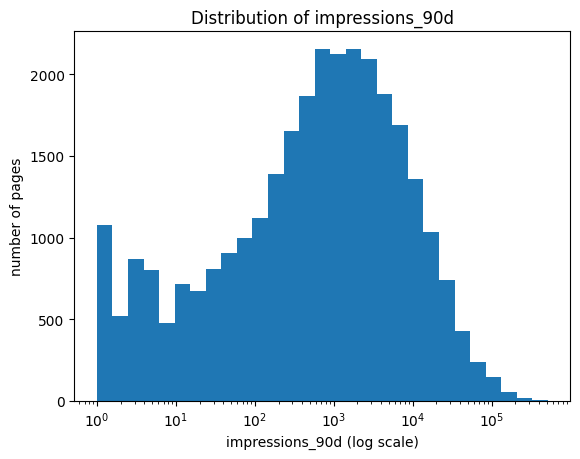

In [5]:
display(df['impressions_90d'].describe())
print(f"Right-skewed: mean ({df['impressions_90d'].mean():.0f}) is far above median ({df['impressions_90d'].median():.0f}), meaning a small number of high-traffic pages pull the average up.")
plt.hist(df['impressions_90d'], bins=np.logspace(0, np.log10(df['impressions_90d'].max()), 30))
plt.xscale('log')
plt.xlabel('impressions_90d (log scale)')
plt.ylabel('number of pages')
plt.title('Distribution of impressions_90d')
plt.show()


In [10]:
suspicious_patterns = df[df['impressions_90d'] <= 11]
display(suspicious_patterns['content_type'].value_counts())
display(df.groupby('content_type')['impressions_90d'].median())
print("Median impressions vary hugely by content type — a 'low' number for one type is normal for another (e.g. feedly article median = 4 vs keyword article median = 955).")

content_type
keyword article       2685
feedly article        1297
comparison article      11
Name: count, dtype: int64

content_type
comparison article    107.0
feedly article          4.0
keyword article       955.0
Name: impressions_90d, dtype: float64

Median impressions vary hugely by content type — a 'low' number for one type is normal for another (e.g. feedly article median = 4 vs keyword article median = 955).


count    30000.000000
mean         0.510733
std          3.279162
min          0.000000
25%          0.000000
50%          0.070000
75%          0.290000
max        100.000000
Name: ctr, dtype: float64

CTR is also right-skewed: median is just 0.07, but a small number of extreme values pull the mean to 0.51.


(array([2.9438e+04, 1.9000e+02, 9.9000e+01, 7.0000e+01, 1.6000e+01,
        2.8000e+01, 2.4000e+01, 3.4000e+01, 4.0000e+00, 4.8000e+01,
        0.0000e+00, 0.0000e+00, 4.0000e+00, 1.0000e+00, 0.0000e+00,
        3.0000e+01, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.1000e+01]),
 array([  0.        ,   3.33333333,   6.66666667,  10.        ,
         13.33333333,  16.66666667,  20.        ,  23.33333333,
         26.66666667,  30.        ,  33.33333333,  36.66666667,
         40.        ,  43.33333333,  46.66666667,  50.        ,
         53.33333333,  56.66666667,  60.        ,  63.33333333,
         66.66666667,  70.        ,  73.33333333,  76.66666667,
         80.        ,  83.33333333,  86.66666667,  90.        ,
         93.33333333,  96.66666667, 100.        ]),
 <BarContainer object of 30 artists>)

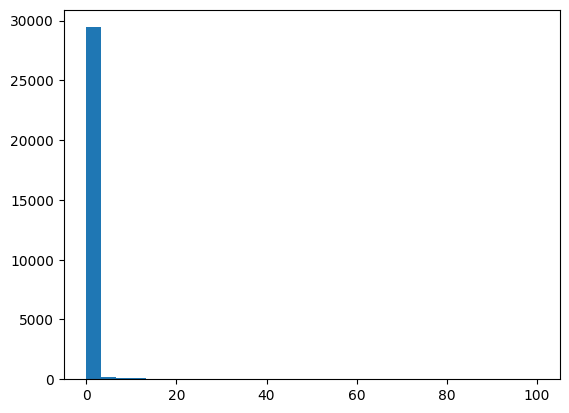

In [11]:
display(df["ctr"].describe())
print(f"CTR is also right-skewed: median is just {df['ctr'].median()}, but a small number of extreme values pull the mean to {df['ctr'].mean():.2f}.")
plt.hist(df['ctr'],bins=30)

'Pages with ctr >= 5: 448 out of 30000 (1.5%)'

count    448.000000
mean      19.563616
std       18.432075
min        5.000000
25%        7.500000
50%       12.500000
75%       25.000000
max      100.000000
Name: ctr, dtype: float64

448 pages (1.5%) have ctr >= 5 — worth checking whether these are real high performers or noise.


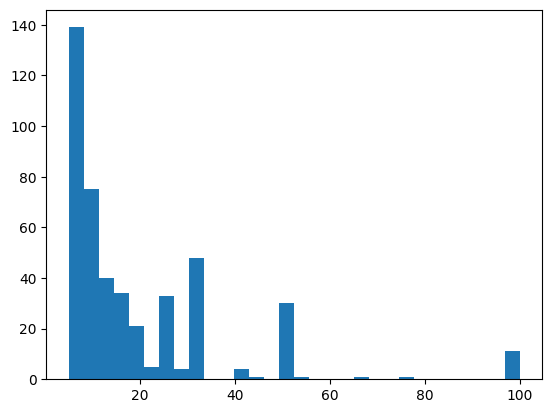

In [12]:
outlier = df[df['ctr'] >= 5]
display(f"Pages with ctr >= 5: {len(outlier)} out of {len(df)} ({len(outlier)/len(df)*100:.1f}%)")
display(outlier['ctr'].describe())
plt.hist(outlier['ctr'],bins=30)
print(f"{len(outlier)} pages ({len(outlier)/len(df)*100:.1f}%) have ctr >= 5 — worth checking whether these are real high performers or noise.")

In [13]:
extreme = df[df['ctr'] >= 40]
display(extreme[['ctr', 'impressions_90d', 'clicks_90d']].describe())
print(f"Median impressions for these {len(extreme)} extreme-CTR pages is just {extreme['impressions_90d'].median():.0f} — this is small-sample noise, not genuine high performance (e.g. 1 click out of 2 impressions = 50% CTR).")

,ctr,impressions_90d,clicks_90d
count,49.000000,49.000000,49.000000
mean,61.258571,2.367347,1.285714
std,21.724458,1.728365,0.790569
min,40.000000,1.000000,1.000000
25%,50.000000,2.000000,1.000000
50%,50.000000,2.000000,1.000000
75%,66.670000,2.000000,1.000000
max,100.000000,9.000000,5.000000


Median impressions for these 49 extreme-CTR pages is just 2 — this is small-sample noise, not genuine high performance (e.g. 1 click out of 2 impressions = 50% CTR).


In [16]:
sus=outlier[outlier['ctr']<=40]
print(sus[['ctr', 'impressions_90d', 'clicks_90d']].describe())
still_low = sus[sus['impressions_90d'] < 20]
print(f"Pages with ctr 5-40 AND impressions < 20: {len(still_low)} out of {len(sus)} ({len(still_low)/len(sus)*100:.1f}%)")
print("78.9% of pages with ctr 5-40 also have under 20 impressions — confirming almost the entire ctr >= 5 group (1.5% of all pages) is unreliable noise, not real signal. CTR should not be trusted as a ranking signal without a minimum-impression guard.")

              ctr  impressions_90d  clicks_90d
count  403.000000       403.000000  403.000000
mean    14.696849        29.677419    2.406948
std      9.483039       158.998264    8.386684
min      5.000000         3.000000    1.000000
25%      7.140000         6.000000    1.000000
50%     11.110000        12.000000    1.000000
75%     20.000000        19.000000    2.000000
max     40.000000      3023.000000  157.000000
Pages with ctr 5-40 AND impressions < 20: 318 out of 403 (78.9%)
78.9% of pages with ctr 5-40 also have under 20 impressions — confirming almost the entire ctr >= 5 group (1.5% of all pages) is unreliable noise, not real signal. CTR should not be trusted as a ranking signal without a minimum-impression guard.


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

In [ ]:
"""
Question 4: Careful words - what I can and can't claim

What this work CAN say:
- Observed: impressions_90d is heavily right-skewed, with a small number of
  high-traffic pages pulling the average far above the median. What counts
  as "low impressions" also depends on content_type - a feedly article with
  a median of 4 impressions is normal for its type, while the same number
  would be alarming for a keyword article (median 955).
- Observed: CTR values above 5 are almost entirely driven by very low
  impression counts (median 2 impressions for ctr >= 40), meaning they
  reflect statistical noise from small samples, not genuine high
  performance. This means CTR should not be trusted as a ranking signal
  without a minimum-impression guard.
- Directional: these patterns suggest that any scoring engine built in this
  project should apply thresholds relative to content_type and impression
  volume, rather than one fixed global cutoff.
- Decision-support: the ranked output this project builds is meant to help
  a reviewer prioritize which pages to look at first - it does not replace
  their judgment, and a high rank is a suggestion to review, not a verdict.

What this work will NEVER say:
- No causal claims: we cannot say a page's low CTR is "caused by" a
  specific factor (a weak title, outdated topic, etc.) just because it
  correlates with one. Correlation observed in this data does not establish
  why a page performs the way it does.
- No predicting Google's algorithm: we have no visibility into how Google's
  search ranking actually works internally - only the outcomes (impressions,
  clicks, position) that result from it.
- No guarantees: flagging a page as a candidate for refresh does not mean
  refreshing it will improve its performance. Without a controlled
  experiment (refresh some pages, compare against similar pages left
  untouched), we cannot separate a real improvement from natural
  fluctuation, seasonality, or regression to the mean.
"""

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.